# 04. Options EDA

Deep dive on `data/strategy_labels.parquet` (64,339 rows, 35 HQ tickers, 2020-01-06 → 2026-03-23).

Two questions, each answered with a table + chart:

1. **Overview** - shape, date range, per-type headline numbers
2. **Year-over-year trend** - has performance degraded or improved over time?

Neither of these requires price prediction - they're describing what the data shows. The price model in 07-08 then targets whatever residual edge exists after these baselines.


In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


LABELS_PATH = Path("output/03_weekly_strategy_labels/strategy_labels.parquet")
OUT_DIR = Path("output/04_options_eda")
OUT_DIR.mkdir(parents=True, exist_ok=True)

IV_BINS = [0.0, 0.30, 0.50, 0.80, 1.20, 10.0]
IV_LABELS = ["< 30", "30-50", "50-80", "80-120", "> 120"]
CALIB_BINS = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0]

## Load + derive columns


In [2]:
labels = pd.read_parquet(LABELS_PATH)
labels["pnl_pct_capital_mark"] = labels["net_pnl_mark"] / labels["capital_per_contract"]
labels["year"] = labels["monday_date"].dt.year
labels["iv_bucket"] = pd.cut(
    labels["iv"], bins=IV_BINS, labels=IV_LABELS, include_lowest=True
)
print(f"Loaded {len(labels):,} rows, {labels['ticker'].nunique()} tickers")
print(
    f"Date range: {labels['monday_date'].min().date()} -> {labels['monday_date'].max().date()}"
)

Loaded 64,339 rows, 35 tickers
Date range: 2020-01-06 -> 2026-03-23


## 1. Overview

Per-type headline: how often did each strategy end up OTM, and what's the realized mean PnL under bid-fill (conservative) and mark-fill (idealized).


In [3]:
print(f"Rows: {len(labels):,}")
print(f"Tickers: {labels['ticker'].nunique()}")
print(
    f"Date range: {labels['monday_date'].min().date()} -> {labels['monday_date'].max().date()}"
)
print(f"Yield targets: {sorted(labels['yield_target'].unique())}")
print(f"Types: {sorted(labels['type'].unique())}")
print()
print("Per type:")
for t, g in labels.groupby("type"):
    print(
        f"  {t}: {len(g):,} rows | "
        f"assigned={100 * g['assigned'].mean():.1f}% | "
        f"mean_pnl_bid={100 * g['pnl_pct_capital'].mean():+.3f}% | "
        f"mean_pnl_mark={100 * g['pnl_pct_capital_mark'].mean():+.3f}%"
    )

Rows: 64,339
Tickers: 35
Date range: 2020-01-06 -> 2026-03-23
Yield targets: [np.float64(0.005), np.float64(0.01), np.float64(0.015), np.float64(0.02), np.float64(0.025), np.float64(0.03), np.float64(0.035), np.float64(0.04), np.float64(0.045), np.float64(0.05)]
Types: ['CC', 'CSP']

Per type:
  CC: 32,941 rows | assigned=32.0% | mean_pnl_bid=-0.466% | mean_pnl_mark=-0.340%
  CSP: 31,398 rows | assigned=32.5% | mean_pnl_bid=-0.056% | mean_pnl_mark=+0.073%


## 2. Year-over-year trend

Tells you whether the strategy has degraded, improved, or stayed the same. If mean PnL declined, premium has gotten thinner (crowded trade). If IV collapsed, premium availability is part of the reason.


In [4]:
year_rows = []
for (year, type_), g in labels.groupby(["year", "type"]):
    if len(g) < 50:
        continue
    pnl = g["pnl_pct_capital"]
    sharpe = float(pnl.mean() / pnl.std()) if pnl.std() > 0 else 0.0
    year_rows.append(
        {
            "year": int(year),
            "type": type_,
            "n": len(g),
            "pct_OTM_at_exp": round(100 * (~g["assigned"]).mean(), 2),
            "mean_pnl_bid_pct": round(100 * pnl.mean(), 3),
            "mean_pnl_mark_pct": round(100 * g["pnl_pct_capital_mark"].mean(), 3),
            "median_iv": round(g["iv"].median(), 3),
            "sharpe_annual": round(sharpe * math.sqrt(52), 3),
        }
    )
year_agg = pd.DataFrame(year_rows)
year_agg

,year,type,n,pct_OTM_at_exp,mean_pnl_bid_pct,mean_pnl_mark_pct,median_iv,sharpe_annual
0,2020,CC,3318,65.58,-0.636,-0.459,0.634,-0.725
1,2020,CSP,3261,72.62,0.616,0.816,0.649,1.763
2,2021,CC,3786,70.34,-0.228,-0.142,0.639,-0.261
3,2021,CSP,3706,67.86,-0.077,0.022,0.639,-0.128
4,2022,CC,4935,73.13,0.097,0.189,0.727,0.139
5,2022,CSP,4901,60.23,-0.529,-0.442,0.756,-0.714
6,2023,CC,4381,60.17,-0.880,-0.761,0.639,-1.284
7,2023,CSP,4064,70.18,0.175,0.279,0.620,0.370
8,2024,CC,5693,64.85,-0.802,-0.649,0.766,-0.880
9,2024,CSP,5241,70.79,-0.054,0.091,0.727,-0.067


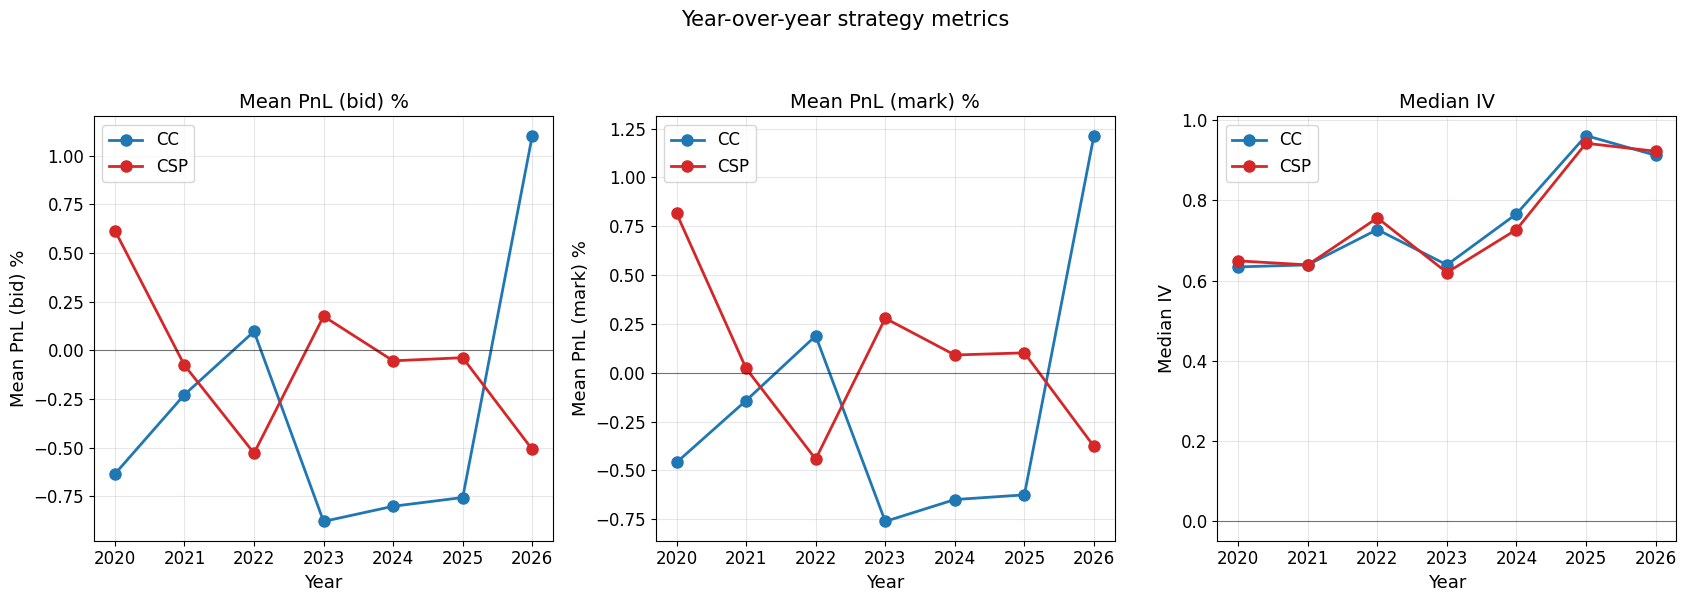

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, metric, title in [
    (axes[0], "mean_pnl_bid_pct", "Mean PnL (bid) %"),
    (axes[1], "mean_pnl_mark_pct", "Mean PnL (mark) %"),
    (axes[2], "median_iv", "Median IV"),
]:
    for t, color in [("CC", "tab:blue"), ("CSP", "tab:red")]:
        sub = year_agg[year_agg["type"] == t]
        ax.plot(
            sub["year"],
            sub[metric],
            marker="o",
            color=color,
            label=t,
            linewidth=2,
            markersize=8,
        )
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Year", fontsize=13)
    ax.set_ylabel(title, fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=12)
fig.suptitle("Year-over-year strategy metrics", fontsize=15, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(OUT_DIR / "year_trend.png", dpi=120)
plt.show()
plt.close(fig)

## 3. Per-ticker yield vs safety frontier

For each (ticker, type, yield target) triplet, compute the median strike distance from spot (% OTM) and the median |delta| at entry. These are the two natural "safety" axes of a weekly short-option position: how far from the stock is the strike sitting, and how much gamma exposure are you accepting. A line per ticker traces its **efficient frontier** - the tradeoff the market offers between weekly yield and strike safety.

Tickers are grouped into Low / Mid / High IV tiers (terciles of each ticker's median IV over the sample). Same-IV-tier tickers fan together because IV sets the scale of the bell curve; within a tier, curves separate by skew, liquidity, and how aggressively the yield-match tolerance had to be stretched.


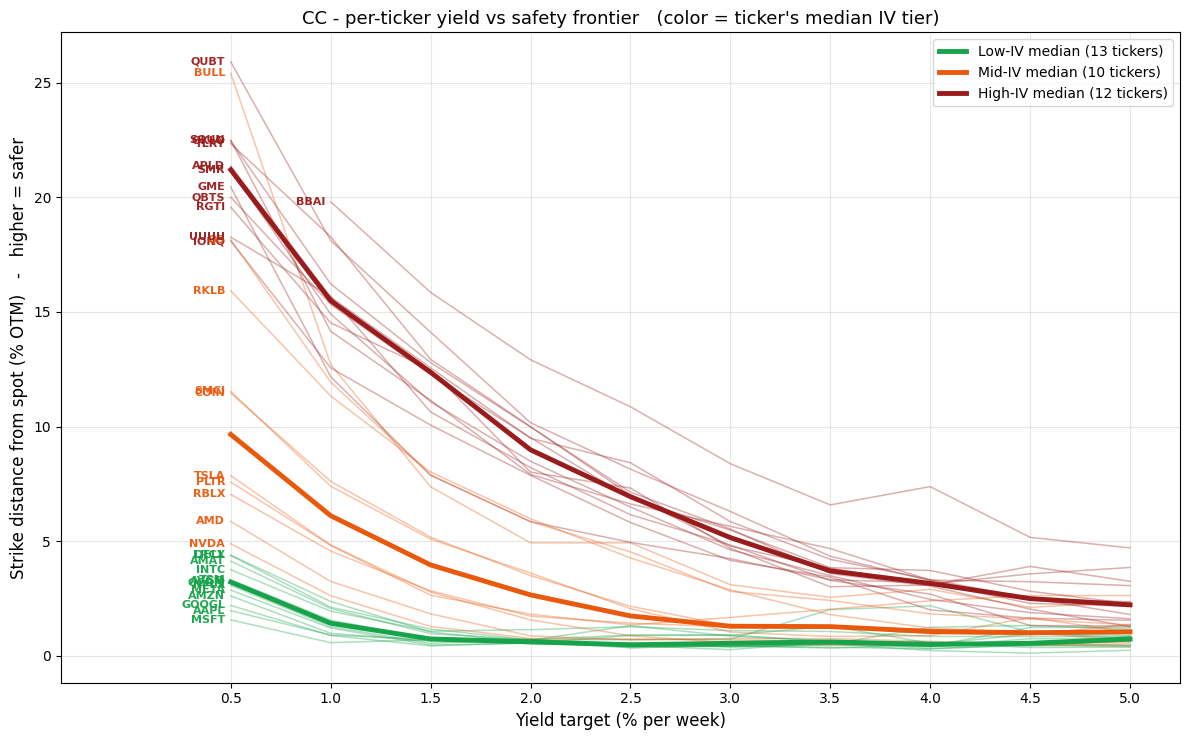

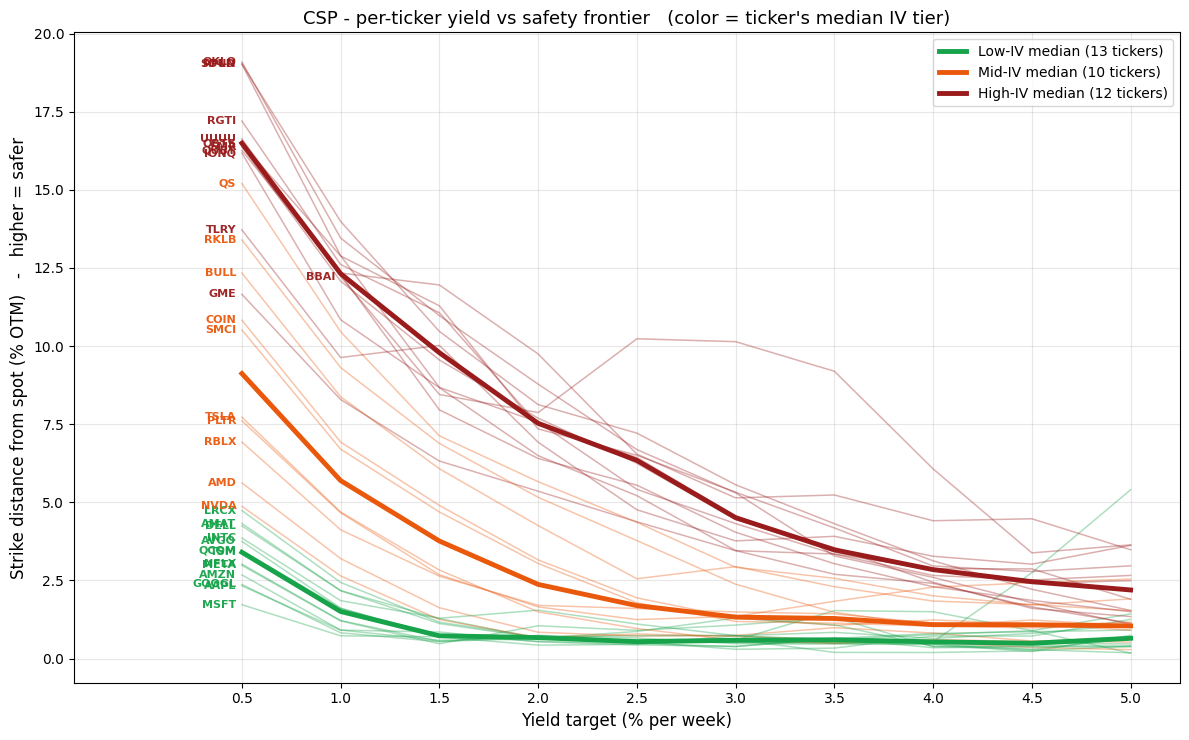

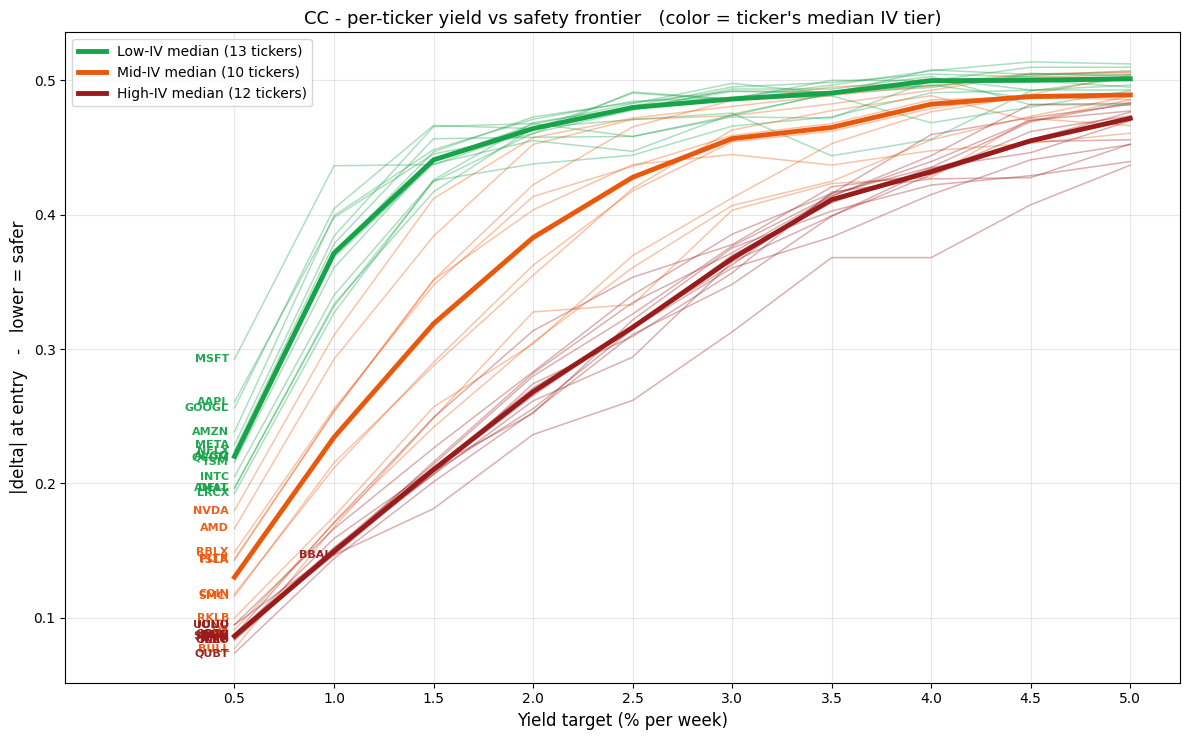

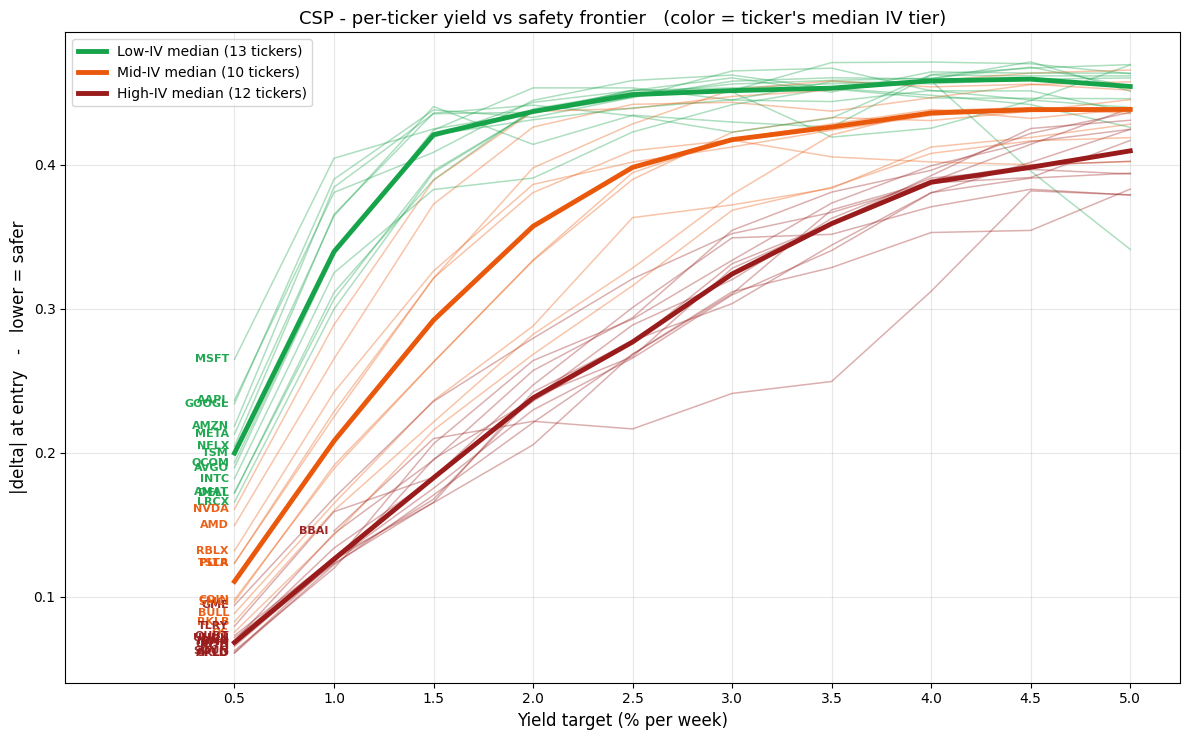


Tier composition:
  Low-IV median-IV 0.34-0.53  (13 tickers): MSFT, GOOGL, AAPL, AMZN, META, TSM, QCOM, AVGO, NFLX, AMAT, DELL, LRCX, INTC
  Mid-IV median-IV 0.57-1.06  (10 tickers): NVDA, AMD, TSLA, PLTR, RBLX, SMCI, COIN, BULL, RKLB, QS
  High-IV median-IV 1.12-1.46  (12 tickers): GME, IONQ, UUUU, SMR, SOUN, TLRY, RGTI, APLD, QBTS, OKLO, QUBT, BBAI


In [6]:
labels["otm_pct"] = (labels["strike"] - labels["monday_close"]).abs() / labels["monday_close"] * 100.0
labels["abs_delta"] = labels["delta"].abs()

ticker_iv_med = labels.groupby("ticker")["iv"].median().sort_values()
low_cut, high_cut = ticker_iv_med.quantile([1 / 3, 2 / 3])


def _tier_of(iv: float) -> str:
    if iv <= low_cut:
        return "Low"
    if iv <= high_cut:
        return "Mid"
    return "High"


ticker_tier = {t: _tier_of(v) for t, v in ticker_iv_med.items()}
tier_colors = {"Low": "#16a34a", "Mid": "#ea580c", "High": "#991b1b"}

frontier = (
    labels.groupby(["ticker", "type", "yield_target"])
    .agg(
        otm_pct_med=("otm_pct", "median"),
        abs_delta_med=("abs_delta", "median"),
        n=("strike", "size"),
    )
    .reset_index()
)

YIELD_TARGETS_SORTED = sorted(labels["yield_target"].unique())

panels = [
    ("otm_pct_med",   "CC",  "Strike distance from spot (% OTM)   -   higher = safer",  "frontier_cc_otm"),
    ("otm_pct_med",   "CSP", "Strike distance from spot (% OTM)   -   higher = safer",  "frontier_csp_otm"),
    ("abs_delta_med", "CC",  "|delta| at entry   -   lower = safer",                    "frontier_cc_delta"),
    ("abs_delta_med", "CSP", "|delta| at entry   -   lower = safer",                    "frontier_csp_delta"),
]

for metric, type_, ylabel, slug in panels:
    fig, ax = plt.subplots(figsize=(12, 7.5))
    for ticker in sorted(frontier["ticker"].unique()):
        sub = frontier[(frontier["ticker"] == ticker) & (frontier["type"] == type_)].sort_values("yield_target")
        if sub.empty:
            continue
        ax.plot(
            sub["yield_target"] * 100,
            sub[metric],
            color=tier_colors[ticker_tier[ticker]],
            alpha=0.35,
            linewidth=1.1,
        )
        # label at leftmost point where lines fan out most
        first = sub.iloc[0]
        ax.annotate(
            ticker,
            xy=(first["yield_target"] * 100, first[metric]),
            xytext=(-4, 0),
            textcoords="offset points",
            fontsize=8,
            color=tier_colors[ticker_tier[ticker]],
            va="center",
            ha="right",
            alpha=0.95,
            fontweight="bold",
        )
    for tier_name in ["Low", "Mid", "High"]:
        tier_tickers = [t for t, tr in ticker_tier.items() if tr == tier_name]
        sub = frontier[(frontier["ticker"].isin(tier_tickers)) & (frontier["type"] == type_)]
        if sub.empty:
            continue
        tier_med = sub.groupby("yield_target")[metric].median().reset_index()
        ax.plot(
            tier_med["yield_target"] * 100,
            tier_med[metric],
            color=tier_colors[tier_name],
            linewidth=3.5,
            label=f"{tier_name}-IV median ({len(tier_tickers)} tickers)",
            zorder=5,
        )
    ax.set_xlabel("Yield target (% per week)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"{type_} - per-ticker yield vs safety frontier   (color = ticker's median IV tier)", fontsize=13)
    ax.grid(alpha=0.3)
    ax.set_xticks([y * 100 for y in YIELD_TARGETS_SORTED])
    ax.set_xlim(-0.35, 5.25)
    ax.legend(loc="best", fontsize=10)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{slug}.png", dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("\nTier composition:")
for tier_name in ["Low", "Mid", "High"]:
    tickers_in = [t for t, tr in ticker_tier.items() if tr == tier_name]
    iv_min = ticker_iv_med[tickers_in].min()
    iv_max = ticker_iv_med[tickers_in].max()
    print(f"  {tier_name}-IV median-IV {iv_min:.2f}-{iv_max:.2f}  ({len(tickers_in)} tickers): {', '.join(tickers_in)}")
